In [1]:
from pathlib import Path
from gensim.models import KeyedVectors
import numpy as np
'''
model_dir = Path.home() / "data" / "GoogleNews-vectors-negative300.bin"

# 50만개의 단어만 활용합니다. 메모리가 충분하다면 limit 파라미터값을 생략하여 300만개를 모두 활용할 수 있습니다.
w2v = KeyedVectors.load_word2vec_format(model_dir, binary=True)'''

'\nmodel_dir = Path.home() / "data" / "GoogleNews-vectors-negative300.bin"\n\n# 50만개의 단어만 활용합니다. 메모리가 충분하다면 limit 파라미터값을 생략하여 300만개를 모두 활용할 수 있습니다.\nw2v = KeyedVectors.load_word2vec_format(model_dir, binary=True)'

In [2]:
'''# print(len(w2v.vocab))   # Gensim 3.X 버전까지는 w2v.vocab을 직접 접근할 수 있습니다.
print(len(w2v.index_to_key))   # Gensim 4.0부터는 index_to_key를 활용해 vocab size를 알 수 있습니다.
print(len(w2v['I']))                    # 혹은 단어를 key로 직접 vector를 얻을 수 있습니다.
print(w2v.vectors.shape)'''

"# print(len(w2v.vocab))   # Gensim 3.X 버전까지는 w2v.vocab을 직접 접근할 수 있습니다.\nprint(len(w2v.index_to_key))   # Gensim 4.0부터는 index_to_key를 활용해 vocab size를 알 수 있습니다.\nprint(len(w2v['I']))                    # 혹은 단어를 key로 직접 vector를 얻을 수 있습니다.\nprint(w2v.vectors.shape)"

In [3]:
# weat 계산
def cos_sim(i, j):
    # 코사인 유사도 
    return np.dot(i, j.T) / (np.linalg.norm(i) * np.linalg.norm(j))


def s(w, A, B):
    c_a = cos_sim(w, A)
    c_b = cos_sim(w, B)

    # 각 속성 집합에 대한 코사인 유사도의 평균
    mean_A = np.mean(c_a, axis=-1)
    mean_B = np.mean(c_b, axis=-1)

    # 양수이면 w가 B보다 A에 더 가깝고, 음수이면 A보다 B에 더 가까움
    return mean_A - mean_B  #, c_a, c_b


def weat_score(X, Y, A, B):
    # 타깃 집합 X와 Y의 각 단어가 속성 집합 A, B 중 어디에 더 가까운지 
    s_X = s(X, A, B)
    s_Y = s(Y, A, B)

    # 각 타깃 집합의 평균 연관성 점수
    mean_X = np.mean(s_X)
    mean_Y = np.mean(s_Y)

    # X와 Y의 연관성 점수를 하나로 합친 뒤 표준편차 계산
    # 집합 내 점수의 자연스러운 변동 크기로 평균 차이를 정규화하기 위해 사용
    std_dev = np.std(np.concatenate([s_X, s_Y], axis=0))

    # WEAT effect size = 두 타깃 집합의 평균 연관성 차 / 전체 연관성 점수의 표준편차
    return (mean_X - mean_Y) / std_dev

In [4]:
'''
#변수, 메모리 정리 
%reset -f 
import gc
if 'w2v' in globals(): del w2v
gc.collect()
print("정리 완료")
'''

'\n#변수, 메모리 정리 \n%reset -f \nimport gc\nif \'w2v\' in globals(): del w2v\ngc.collect()\nprint("정리 완료")\n'

In [5]:
import os

data_dir = os.path.join(os.getenv("HOME"), "data")
file_name = os.path.join(data_dir, "synopsis.txt")

with open(file_name, 'r') as file:
    for i in range(20):
        print(file.readline(), end='')

사운드 엔지니어 상우(유지태 분)는 치매에 걸린 할머니(백성희 분)와
 젊은 시절 상처한 한 아버지(박인환 분), 고모(신신애 분)와 함께 살고 있다.
 어느 겨울 그는 지방 방송국 라디오 PD 은수(이영애 분)를 만난다.
 자연의 소리를 채집해 틀어주는 라디오 프로그램을 준비하는 은수는 상우와 녹음 여행을 떠난다.
 자연스레 가까워지는 두 사람은 어느 날, 은수의 아파트에서 밤을 보낸다.
 너무 쉽게 사랑에 빠진 두 사람... 상우는 주체할 수 없을 정도로 그녀에게 빨려든다.
 그러나 겨울에 만난 두 사람의 관계는 봄을 지나 여름을 맞이하면서 삐걱거린다.
 이혼 경험이 있는 은수는 상우에게 결혼할 생각이 없다며 부담스러운 표정을 내비친다.
 "어떻게 사랑이 변하니?..."라고 묻는 상우에게 은수는 그저 "헤어져" 라고 단호하게 말한다.
 영원히 변할 것 같지 않던 사랑이 변하고, 그 사실을 받아들이지 못하는 상우는 어찌 할 바를 모른다.
 은수를 잊지 못하는 상우는 미련과 집착의 감정을 이기지 못하고 서울과 강릉을 오간다.
유사 이래 연령, 성별, 빈부의 차이와 정치적인 입장을 불문하고 일거에 국민을 통합해 온 '애국심'이라는 성역에 일침을 가하는 다큐멘터리. 재작년 전국 민족민주 유가족협의회의 장기농성을 다룬 인상적인 다큐멘터리 <민들레>를 만들었던 독립영화집단 '빨간 눈사람'이 우리 사회 구석구석을 발빠르게 돌아다니며 애국심과 민족주의가 강요되는 현장을 발굴하여 카메라에 담았다. 박홍 서강대 명예총장, 이도형 '한국논단' 발행인, 축구해설자 신문선, 홍세화, 박노해 등 사회 각계의 '스타'들이 등장해 저마다의 확고한 신념을 성토한다. 감독 이경순과 최하동하는 이 작품을 위해 3년간 백여 명을 인터뷰했다고 한다. 2001 올해의 독립영화상 수상.
 민족과 국가란 공동체에서 부단히 권력과 부를 얻는 자, 나아가 민족과 국가란 공동체에서 얻은 신분과 부귀를 영원히 그의 자손에게 대물림하려는 자, 그래서 민족과 국가란 공동체를 부단히 유지해야만 하는 자, 따라서

In [6]:
# 명사만 tokenized로 저장 
from konlpy.tag import Okt

okt = Okt()
tokenized = []

with open(file_name, 'r') as file:
    while True:
        line = file.readline()
        if not line: break
        words = okt.pos(line, stem=True, norm=True)
        res = []
        for w in words:
            if w[1] in ["Noun"]:      # "Adjective", "Verb" 등을 포함할 수도 있습니다.
                res.append(w[0])    # 명사일 때만 tokenized 에 저장하게 됩니다.
        tokenized.append(res)

print("슝~")

슝~


In [7]:
print(len(tokenized))

71156


In [8]:
# embedding model 만들기 
from gensim.models import Word2Vec

# tokenized에 담긴 데이터를 가지고 나만의 Word2Vec을 생성합니다. (Gensim 4.0 기준)
model = Word2Vec(tokenized, vector_size=100, window=5, min_count=3, sg=0)
model.wv.most_similar(positive=['영화'])

[('작품', 0.8884985446929932),
 ('다큐멘터리', 0.8354318141937256),
 ('드라마', 0.8199501037597656),
 ('영화로', 0.8164547681808472),
 ('형식', 0.789732813835144),
 ('주제', 0.7856284976005554),
 ('코미디', 0.7838046550750732),
 ('소재', 0.7819544076919556),
 ('편의', 0.770527720451355),
 ('설정', 0.769014298915863)]

In [9]:
model.wv.most_similar(positive=['사랑'])

[('시빌라', 0.7240068316459656),
 ('첫사랑', 0.7127886414527893),
 ('만남', 0.694439172744751),
 ('행복', 0.6941394209861755),
 ('애정', 0.6869353652000427),
 ('이별', 0.6820833086967468),
 ('연애', 0.6792796850204468),
 ('토마슈', 0.6754655838012695),
 ('가슴', 0.665735125541687),
 ('아픔', 0.6634963154792786)]

In [10]:
model.wv.most_similar(positive=['연극'])

[('영감', 0.8824248313903809),
 ('연기자', 0.8755152225494385),
 ('시나리오', 0.8695480227470398),
 ('대본', 0.8651912212371826),
 ('배우', 0.8595724701881409),
 ('영화감독', 0.8572644591331482),
 ('연기', 0.8558332920074463),
 ('팬', 0.8512775301933289),
 ('공연', 0.8512306809425354),
 ('캐스팅', 0.8511644005775452)]

In [11]:

import os
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from konlpy.tag import Okt

art_txt = 'synopsis_art.txt'
gen_txt = 'synopsis_gen.txt'

def read_token(file_name):
    okt = Okt()
    result = []
    with open(data_dir + '/' + file_name, 'r') as fread:
        print(file_name, '파일을 읽고 있습니다.')
        while True:
            line = fread.readline()
            if not line: break
            tokenlist = okt.pos(line, stem=True, norm=True)
            for word in tokenlist:
                if word[1] in ["Noun"]:#, "Adjective", "Verb"]:
                    result.append((word[0]))
    return ' '.join(result)

print("슝~")

슝~


In [12]:
# 2개의 파일을 처리하는데 10분 가량 걸립니다.
art = read_token(art_txt)
gen = read_token(gen_txt)

synopsis_art.txt 파일을 읽고 있습니다.
synopsis_gen.txt 파일을 읽고 있습니다.


WEAT - X:예술영화, Y:상업영화, A:드라마 등등, B:액션 등등 에 대응하는 단어들을 고르기 위해 TF-IDF 사용 


가정 : 예술영화를 잘 대표하는 단어란 예술영화 시놉시스에는 자주 나타나지만 그 외 다른 구분의 영화(예를 들어 일반영화) 시놉시스에는 자주 나타나지 않는 것을 고르는 것이 적당할 것 --> 여기에 적당한게 TF-IDF

In [13]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform([art, gen])

print(X.shape)

print(vectorizer.vocabulary_['영화'])
print(vectorizer.get_feature_names_out()[23976])

(2, 41082)
23976
영화


In [14]:
m1 = X[0].tocoo()   # art를 TF-IDF로 표현한 sparse matrix를 가져옵니다.
m2 = X[1].tocoo()   # gen을 TF-IDF로 표현한 sparse matrix를 가져옵니다.

w1 = [[i, j] for i, j in zip(m1.col, m1.data)]
w2 = [[i, j] for i, j in zip(m2.col, m2.data)]

w1.sort(key=lambda x: x[1], reverse=True)   #art를 구성하는 단어들을 TF-IDF가 높은 순으로 정렬합니다.
w2.sort(key=lambda x: x[1], reverse=True)   #gen을 구성하는 단어들을 TF-IDF가 높은 순으로 정렬합니다.

print('예술영화를 대표하는 단어들:')
for i in range(100):
    print(vectorizer.get_feature_names_out()[w1[i][0]], end=', ')

print('\n')

print('일반영화를 대표하는 단어들:')
for i in range(100):
    print(vectorizer.get_feature_names_out()[w2[i][0]], end=', ')

예술영화를 대표하는 단어들:
그녀, 자신, 시작, 위해, 사랑, 사람, 영화, 친구, 남자, 가족, 이야기, 마을, 사건, 마음, 세상, 아버지, 아이, 엄마, 모든, 여자, 대한, 서로, 과연, 다시, 시간, 아들, 소녀, 아내, 다른, 사이, 영화제, 세계, 사실, 하나, 점점, 남편, 감독, 여행, 인생, 발견, 모두, 순간, 우리, 가장, 마지막, 생활, 아빠, 모습, 통해, 죽음, 기억, 비밀, 학교, 음악, 한편, 소년, 생각, 도시, 명의, 사고, 결혼, 전쟁, 때문, 위기, 이제, 최고, 이자, 과거, 일상, 경찰, 상황, 간다, 미국, 결심, 운명, 현실, 관계, 지금, 단편, 여인, 하루, 이름, 이후, 준비, 인간, 감정, 만난, 국제, 처음, 충격, 살인, 누구, 동안, 존재, 그린, 어머니, 연인, 계속, 동생, 작품, 

일반영화를 대표하는 단어들:
자신, 그녀, 영화제, 위해, 사람, 시작, 국제, 영화, 친구, 사랑, 남자, 이야기, 대한, 서울, 여자, 사건, 남편, 아이, 가족, 아버지, 다른, 마을, 시간, 엄마, 아들, 모든, 단편, 마음, 사실, 다시, 세계, 모습, 작품, 통해, 생각, 서로, 세상, 발견, 감독, 아내, 관계, 소녀, 사이, 하나, 우리, 애니메이션, 때문, 여성, 죽음, 과연, 점점, 인간, 생활, 한편, 결혼, 상황, 모두, 기억, 명의, 소년, 여행, 가장, 간다, 순간, 이제, 도시, 비밀, 학교, 과거, 가지, 이자, 경찰, 마지막, 미국, 동안, 전쟁, 주인공, 대해, 존재, 현실, 연출, 사고, 살인, 일상, 어머니, 계속, 사회, 인생, 다큐멘터리, 부문, 섹스, 최고, 바로, 동생, 의도, 하루, 위기, 계획, 정체, 한국, 

In [15]:
# 중복을 제거하고 상위 n=15개 단어 추출
n = 15
w1_, w2_ = [], []
for i in range(100):
    w1_.append(vectorizer.get_feature_names_out()[w1[i][0]])
    w2_.append(vectorizer.get_feature_names_out()[w2[i][0]])

# w1에만 있고 w2에는 없는, 예술영화를 잘 대표하는 단어를 15개 추출한다.
target_art, target_gen = [], []
for i in range(100):
    if (w1_[i] not in w2_) and (w1_[i] in model.wv): target_art.append(w1_[i])
    if len(target_art) == n: break

# w2에만 있고 w1에는 없는, 일반영화를 잘 대표하는 단어를 15개 추출한다.
for i in range(100):
    if (w2_[i] not in w1_) and (w2_[i] in model.wv): target_gen.append(w2_[i])
    if len(target_gen) == n: break


In [16]:
print(target_art)
print(target_gen)

['아빠', '음악', '결심', '운명', '지금', '여인', '이름', '이후', '준비', '감정', '만난', '처음', '충격', '누구', '그린']
['서울', '애니메이션', '여성', '가지', '주인공', '대해', '연출', '사회', '다큐멘터리', '부문', '섹스', '바로', '의도', '계획', '정체']


In [17]:
# 같은 방법으로 장르별 대표 단어도 추출
genre_txt = [
    'synopsis_SF.txt', 'synopsis_family.txt', 'synopsis_show.txt',
    'synopsis_horror.txt', 'synopsis_etc.txt',
    'synopsis_documentary.txt', 'synopsis_drama.txt',
    'synopsis_romance.txt', 'synopsis_musical.txt',
    'synopsis_mystery.txt', 'synopsis_crime.txt',
    'synopsis_historical.txt', 'synopsis_western.txt',
    'synopsis_adult.txt', 'synopsis_thriller.txt',
    'synopsis_animation.txt', 'synopsis_action.txt',
    'synopsis_adventure.txt', 'synopsis_war.txt',
    'synopsis_comedy.txt', 'synopsis_fantasy.txt'
]

genre_name = [
    'SF', '가족', '공연', '공포(호러)', '기타', '다큐멘터리',
    '드라마', '멜로로맨스', '뮤지컬', '미스터리', '범죄', '사극',
    '서부극(웨스턴)', '성인물(에로)', '스릴러', '애니메이션',
    '액션', '어드벤처', '전쟁', '코미디', '판타지'
]

In [18]:
# 약 10분정도 걸립니다.
genre = []
for file_name in genre_txt:
    genre.append(read_token(file_name))

synopsis_SF.txt 파일을 읽고 있습니다.
synopsis_family.txt 파일을 읽고 있습니다.
synopsis_show.txt 파일을 읽고 있습니다.
synopsis_horror.txt 파일을 읽고 있습니다.
synopsis_etc.txt 파일을 읽고 있습니다.
synopsis_documentary.txt 파일을 읽고 있습니다.
synopsis_drama.txt 파일을 읽고 있습니다.
synopsis_romance.txt 파일을 읽고 있습니다.
synopsis_musical.txt 파일을 읽고 있습니다.
synopsis_mystery.txt 파일을 읽고 있습니다.
synopsis_crime.txt 파일을 읽고 있습니다.
synopsis_historical.txt 파일을 읽고 있습니다.
synopsis_western.txt 파일을 읽고 있습니다.
synopsis_adult.txt 파일을 읽고 있습니다.
synopsis_thriller.txt 파일을 읽고 있습니다.
synopsis_animation.txt 파일을 읽고 있습니다.
synopsis_action.txt 파일을 읽고 있습니다.
synopsis_adventure.txt 파일을 읽고 있습니다.
synopsis_war.txt 파일을 읽고 있습니다.
synopsis_comedy.txt 파일을 읽고 있습니다.
synopsis_fantasy.txt 파일을 읽고 있습니다.


In [19]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(genre)

print(X.shape)

(21, 42191)


In [20]:
m = [X[i].tocoo() for i in range(X.shape[0])]

w = [[[i, j] for i, j in zip(mm.col, mm.data)] for mm in m]

for i in range(len(w)):
    w[i].sort(key=lambda x: x[1], reverse=True)
attributes = []
for i in range(len(w)):
    print(genre_name[i], end=': ')
    attr = []
    j = 0
    while (len(attr) < 15):
        if vectorizer.get_feature_names_out()[w[i][j][0]] in model.wv:
            attr.append(vectorizer.get_feature_names_out()[w[i][j][0]])
            print(vectorizer.get_feature_names_out()[w[i][j][0]], end=', ')
        j += 1
    attributes.append(attr)
    print()

SF: 위해, 자신, 지구, 시작, 사람, 인류, 인간, 미래, 우주, 그녀, 로봇, 세계, 모든, 박사, 우주선, 
가족: 엄마, 아빠, 가족, 영화제, 자신, 위해, 친구, 아주르, 아버지, 시작, 그녀, 아들, 마을, 국제, 낙타, 
공연: 오페라, 사랑, 토스카, 실황, 올레, 자신, 카바, 그녀, 공연, 오텔로, 리골레토, 백작, 프레, 베르디, 위해, 
공포(호러): 시작, 위해, 사람, 자신, 친구, 그녀, 사건, 공포, 발견, 죽음, 마을, 가족, 악령, 남자, 좀비, 
기타: 영화제, 국제, 서울, 단편, 영화, 자신, 사람, 이야기, 그녀, 남자, 위해, 시작, 사랑, 뉴미디어, 페스티벌, 
다큐멘터리: 영화제, 영화, 다큐, 국제, 다큐멘터리, 사람, 이야기, 대한, 자신, 감독, 위해, 서울, 우리, 시작, 세계, 
드라마: 자신, 영화제, 그녀, 사람, 사랑, 영화, 위해, 시작, 국제, 남자, 친구, 이야기, 엄마, 여자, 아버지, 
멜로로맨스: 그녀, 사랑, 자신, 시작, 남편, 남자, 여자, 사람, 친구, 섹스, 위해, 마음, 결혼, 서로, 아내, 
뮤지컬: 뮤지컬, 사랑, 에스메랄다, 그녀, 음악, 충무로, 모차르트, 영화, 토스카, 자신, 니웨, 카바, 영화제, 바흐, 페뷔스, 
미스터리: 사건, 그녀, 시작, 자신, 위해, 사람, 발견, 사고, 진실, 죽음, 기억, 살인, 친구, 아내, 남자, 
범죄: 사건, 위해, 자신, 경찰, 시작, 그녀, 범죄, 조직, 살인, 사람, 마약, 형사, 남자, 모든, 살해, 
사극: 조선, 위해, 시작, 신기전, 사랑, 자신, 아가멤논, 황제, 그녀, 루안, 최고, 운명, 사람, 하선, 전쟁, 
서부극(웨스턴): 서부, 보안관, 위해, 벌린, 카우보이, 그레이프바인, 헨리, 마을, 자신, 개릿, 아이, 시작, 무법자, 프린트, 마적, 
성인물(에로): 그녀, 남편, 마사지, 자신, 섹스, 관계, 영화, 정사, 남자, 위해, 시작, 여자, 유부녀, 마음, 사랑, 
스릴러: 자신, 그녀, 사건, 

In [21]:
matrix = [[0 for _ in range(len(genre_name))] for _ in range(len(genre_name))]
print("슝~")

슝~


In [22]:
X = np.array([model.wv[word] for word in target_art])
Y = np.array([model.wv[word] for word in target_gen])

for i in range(len(genre_name)-1):
    for j in range(i+1, len(genre_name)):
        A = np.array([model.wv[word] for word in attributes[i]])
        B = np.array([model.wv[word] for word in attributes[j]])
        matrix[i][j] = weat_score(X, Y, A, B)

print("슝~")

슝~


In [23]:
for i in range(len(genre_name)-1):
    for j in range(i+1, len(genre_name)):
        print(genre_name[i], genre_name[j],matrix[i][j])

SF 가족 -0.5002947
SF 공연 -0.37805513
SF 공포(호러) -0.67292863
SF 기타 0.39120242
SF 다큐멘터리 0.6263692
SF 드라마 -0.33755997
SF 멜로로맨스 -0.79304487
SF 뮤지컬 0.37443733
SF 미스터리 -0.6659064
SF 범죄 -0.19390388
SF 사극 -0.81815827
SF 서부극(웨스턴) -0.41647044
SF 성인물(에로) -0.5834607
SF 스릴러 -0.51274204
SF 애니메이션 0.42289484
SF 액션 -0.45835352
SF 어드벤처 -0.77980185
SF 전쟁 0.23437023
SF 코미디 -0.41826195
SF 판타지 -0.13638775
가족 공연 0.15072198
가족 공포(호러) -0.17497791
가족 기타 0.77982885
가족 다큐멘터리 0.85104024
가족 드라마 0.25717112
가족 멜로로맨스 -0.6354402
가족 뮤지컬 0.71472526
가족 미스터리 -0.2910484
가족 범죄 0.24204223
가족 사극 -0.09924172
가족 서부극(웨스턴) 0.39603603
가족 성인물(에로) -0.34327006
가족 스릴러 -0.12732859
가족 애니메이션 0.8950882
가족 액션 0.09722886
가족 어드벤처 -0.040254124
가족 전쟁 0.62775475
가족 코미디 0.2111838
가족 판타지 0.4523924
공연 공포(호러) -0.23440917
공연 기타 0.9871637
공연 다큐멘터리 0.9558007
공연 드라마 0.1097563
공연 멜로로맨스 -0.7099749
공연 뮤지컬 0.9179923
공연 미스터리 -0.32441756
공연 범죄 0.12602621
공연 사극 -0.3385269
공연 서부극(웨스턴) 0.07822691
공연 성인물(에로) -0.49865946
공연 스릴러 -0.19032864
공연 애니메이션 0.96169597
공연 액션 -

In [24]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')

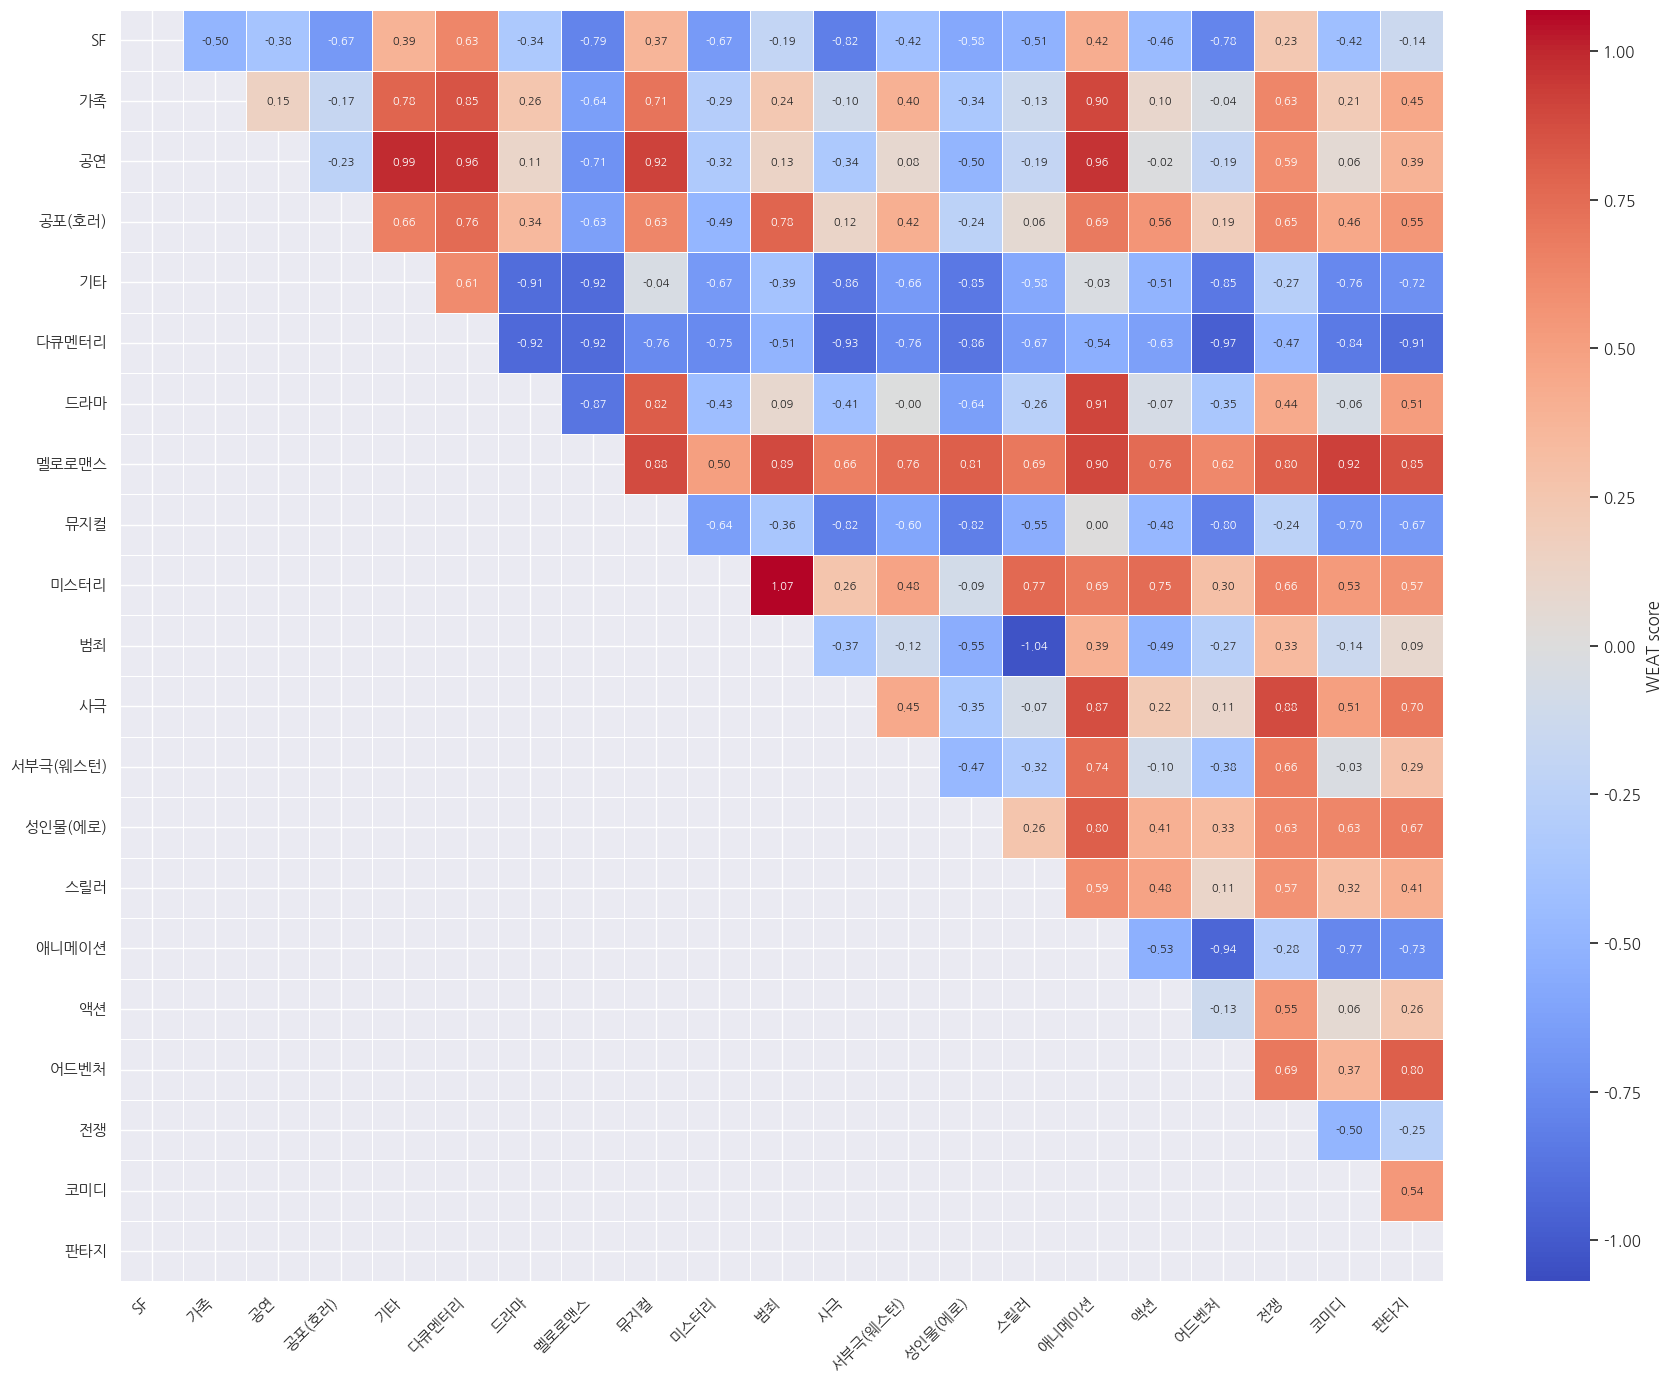

In [25]:
import numpy as np;
import seaborn as sns;

np.random.seed(0)

# 한글 지원 폰트
sns.set(font='NanumGothic')

# 마이너스 부호
plt.rcParams['axes.unicode_minus'] = False

# matrix가 list 형태라면 numpy array로 변환
matrix_np = np.array(matrix, dtype=float)

# 계산하지 않은 하삼각형과 대각선 숨기기
# 기존 matrix는 i < j인 위쪽 삼각형만 계산했으므로,
# 아래쪽 0들은 "편향 없음"이 아니라 "계산 안 함"임
mask = np.tril(np.ones_like(matrix_np, dtype=bool))

# 색상 범위를 양수/음수 대칭으로 맞추기
valid_values = matrix_np[~mask]
max_abs = np.max(np.abs(valid_values))

plt.figure(figsize=(18, 14))

sns.heatmap(
    matrix_np,
    mask=mask,
    xticklabels=genre_name,
    yticklabels=genre_name,
    cmap="coolwarm",
    center=0,
    vmin=-max_abs,
    vmax=max_abs,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.5,
    cbar_kws={"label": "WEAT score"}
)


plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

결과해석  
드라마, 멜로로맨스 = -0.83 -> 멜로로맨스가 드라마보다 더 예술영화 쪽에 가깝다  
멜로로맨스, 코미디 = 0.91 -> 멜로로맨스가 코미디보다 더 예술영화 쪽에 가깝다  
멜로로맨스, 전쟁 = 0.82 -> 멜로로맨스가 전쟁보다 더 예술영화 쪽에 가깝다   
액션, 공포 = -0.36 -> 공포가 액션보다 살짝 더 예술영화 쪽에 가깝다


In [26]:
import numpy as np
import pandas as pd

matrix_np = np.array(matrix, dtype=float)
n = len(genre_name)

genre_scores = []

for k in range(n):
    scores = []

    for i in range(n):
        for j in range(i + 1, n):
            score = matrix_np[i][j]

            # k가 행 장르 A일 때:
            # score > 0이면 k가 예술영화 쪽
            if k == i:
                scores.append(score)

            # k가 열 장르 B일 때:
            # score < 0이면 k가 예술영화 쪽
            # 따라서 k 입장 점수는 -score로 봐야 함
            elif k == j:
                scores.append(-score)

    genre_scores.append({
        "genre": genre_name[k],
        "mean_art_association": np.mean(scores),
        "abs_mean": abs(np.mean(scores)),
        "num_comparisons": len(scores)
    })

genre_score_df = pd.DataFrame(genre_scores)
genre_score_df = genre_score_df.sort_values(
    "mean_art_association",
    ascending=False
)

genre_score_df

,genre,mean_art_association,abs_mean,num_comparisons
7,멜로로맨스,0.776083,0.776083,20
9,미스터리,0.487823,0.487823,20
13,성인물(에로),0.461201,0.461201,20
11,사극,0.346344,0.346344,20
3,공포(호러),0.329279,0.329279,20
17,어드벤처,0.296285,0.296285,20
14,스릴러,0.250273,0.250273,20
1,가족,0.223197,0.223197,20
2,공연,0.145227,0.145227,20
6,드라마,0.056856,0.056856,20


In [27]:
from collections import Counter

all_attribute_words = [word for genre_words in attributes for word in genre_words]
word_counts = Counter(all_attribute_words)

duplicate_word_df = pd.DataFrame(
    [
        {"word": word, "count": count}
        for word, count in word_counts.items()
        if count >= 2
    ],
    columns=["word", "count"]
).sort_values(["count", "word"], ascending=[False, True]).reset_index(drop=True)

duplicate_word_df

,word,count
0,자신,21
1,위해,20
2,시작,19
3,그녀,16
4,사람,16
5,남자,10
6,친구,10
7,사랑,9
8,영화,8
9,영화제,8


---

### 장르별 후보 단어 선정 개선안 

10위정도까지의 단어가 과하게 등장하여 사실상 의미 없는 데이터로 작용했을 가능성이 있을 것으로 보여, 과하게 많이 나오는 단어들은 지우되 무작정 순위 기반으로만 삭제해버리면 '마을' '사건' 같은 경우는 장르성이 짙어 꽤 의미있지만 자주 등장하는 단어이기에 이들은 남겨둘 수 있게 하기 위해 다음 방식으로 개선한다.  

1. Stopword(너무 많이 등장하거나 그 자체로 의미가 없는 단어로 무조건 삭제) :  
 자신(21), 위해(20), 시작(19), 그녀(16), 사람(16), 남자(10), 영화(8), 영화제(8)   

2. TF-IDF와 genre_idf를 결합한 차등 점수제  
등장 자체는 많이 했지만 장르성을 크게 해치지 않는 단어(사건, 가족 등등) :   

    장르별 TF-IDF 최댓값을 기준으로 각 단어의 점수를 정규화한 후 각 단어가 여러 장르의 후보 목록에 포함될수록 장르 구분력이 낮다고 보고 감점을 적용하되, genre_idf를 로그 연산을 통해 완만한 감점을 적용하여 여러 장르에서 사용되더라도 충분히 높은 TF-IDF를 가졌다면 최종 대표단어로 계속 남을 수 있도록 한다.  

  
    ` genre_idf = np.log((num_genres + 1) / (genre_df + 1)) + 1 `    
    ` final_score = tfidf_score * genre_idf `



이 방식을 적용하면 대표 단어 리스트가 작아지니 애초에 50개의 후보를 뽑아 계산한다.



In [28]:
from collections import Counter
from IPython.display import display

STOPWORDS = {"자신", "위해", "시작", "그녀", "사람", "남자", "영화", "영화제"}
CANDIDATE_SIZE = 50
FINAL_SIZE = 15

# 앞의 WEAT 계산 셀에서 X가 Word2Vec 배열로 덮어써지므로 별도 변수로 다시 생성합니다.
genre_vectorizer_improved = TfidfVectorizer()
genre_tfidf_matrix = genre_vectorizer_improved.fit_transform(genre)
feature_names = genre_vectorizer_improved.get_feature_names_out()

m_improved = [genre_tfidf_matrix[i].tocoo() for i in range(genre_tfidf_matrix.shape[0])]
w_improved = [
    sorted(zip(mm.col, mm.data), key=lambda item: item[1], reverse=True)
    for mm in m_improved
]

# 1단계: stopword와 Word2Vec 미등록 단어를 제외한 장르별 후보 50개 수집
genre_candidates = []
for genre_idx, ranked_words in enumerate(w_improved):
    candidates = []

    for feature_idx, tfidf_value in ranked_words:
        word = feature_names[feature_idx]

        if word in STOPWORDS or word not in model.wv:
            continue

        candidates.append({
            "genre": genre_name[genre_idx],
            "word": word,
            "original_tfidf": float(tfidf_value),
        })

        if len(candidates) == CANDIDATE_SIZE:
            break

    if len(candidates) < FINAL_SIZE:
        raise ValueError(
            f"{genre_name[genre_idx]} 장르의 유효 후보가 {len(candidates)}개뿐입니다. "
            f"최종 대표 단어 {FINAL_SIZE}개를 선택할 수 없습니다."
        )

    genre_candidates.append(candidates)

# 2단계: 각 단어가 후보로 포함된 장르 수(genre_df) 계산
genre_df_counter = Counter(
    word
    for candidates in genre_candidates
    for word in {candidate["word"] for candidate in candidates}
)

# 3단계: 장르별 TF-IDF 정규화와 로그 IDF를 결합해 최종 점수 계산
num_genres = len(genre_candidates)
score_records = []

for genre_idx, candidates in enumerate(genre_candidates):
    max_tfidf = max(candidate["original_tfidf"] for candidate in candidates)

    for candidate in candidates:
        tfidf_score = candidate["original_tfidf"] / max_tfidf
        genre_df = genre_df_counter[candidate["word"]]
        genre_idf = np.log((num_genres + 1) / (genre_df + 1)) + 1
        final_score = tfidf_score * genre_idf

        score_records.append({
            "_genre_index": genre_idx,
            "genre": candidate["genre"],
            "word": candidate["word"],
            "original_tfidf": candidate["original_tfidf"],
            "tfidf_score": tfidf_score,
            "genre_df": genre_df,
            "genre_idf": genre_idf,
            "final_score": final_score,
        })

score_columns = [
    "genre", "word", "original_tfidf", "tfidf_score",
    "genre_df", "genre_idf", "final_score"
]

_improved_score_df = pd.DataFrame(score_records).sort_values(
    ["_genre_index", "final_score", "original_tfidf", "word"],
    ascending=[True, False, False, True]
)
improved_score_df = _improved_score_df[score_columns].reset_index(drop=True)

_improved_selected_df = _improved_score_df.groupby(
    "_genre_index", sort=False
).head(FINAL_SIZE)
improved_selected_score_df = _improved_selected_df[score_columns].reset_index(drop=True)

attributes_improved = [
    group["word"].tolist()
    for _, group in _improved_selected_df.groupby("_genre_index", sort=False)
]

# 구현 검증
all_candidate_words = [
    candidate["word"]
    for candidates in genre_candidates
    for candidate in candidates
]
assert STOPWORDS.isdisjoint(all_candidate_words)
assert len(attributes_improved) == len(genre_name)
assert all(len(words) == FINAL_SIZE for words in attributes_improved)
assert all(
    genre_df == genre_df_counter[word]
    for word, genre_df in zip(
        improved_score_df["word"], improved_score_df["genre_df"]
    )
)
assert np.allclose(
    improved_score_df["final_score"],
    improved_score_df["tfidf_score"] * improved_score_df["genre_idf"]
)

print("개선된 장르별 대표 단어")
for genre_label, words in zip(genre_name, attributes_improved):
    print(f"{genre_label}: {', '.join(words)}")


개선된 장르별 대표 단어
SF: 인류, 지구, 미래, 로봇, 우주, 박사, 인간, 우주선, 외계, 행성, 존재, 실험, 능력, 세계, 시스템
가족: 아빠, 아주르, 엄마, 낙타, 할머니, 씨제이, 동구, 가족, 슈이트, 학교, 국제, 마갈, 미아, 펠리칸, 친구
공연: 오페라, 실황, 토스카, 올레, 카바, 오텔로, 리골레토, 백작, 프레, 공연, 베르디, 비바, 콘서트, 백작부인, 카르피
공포(호러): 공포, 악령, 좀비, 사건, 친구, 죽음, 저주, 발견, 이후, 일행, 악몽, 살인, 병원, 의문, 실종
기타: 단편, 서울, 국제, 뉴미디어, 페스티벌, 아시아나, 독립, 연출, 이미지, 부산, 이야기, 상영작, 지하철, 청소년, 우리
다큐멘터리: 다큐, 다큐멘터리, 국제, 감독, 우리, 서울, 한국, 여성, 환경, 사회, 통해, 노동자, 대한, 기록, 세계
드라마: 국제, 단편, 사랑, 서울, 엄마, 남편, 여자, 마음, 감독, 친구, 부문, 연출, 간다, 어머니, 이야기
멜로로맨스: 남편, 섹스, 사랑, 여자, 마음, 부부, 결혼, 관계, 연애, 서로, 애인, 친구, 유혹, 회사, 새엄마
뮤지컬: 뮤지컬, 에스메랄다, 충무로, 모차르트, 니웨, 음악, 바흐, 토스카, 카바, 페뷔스, 프롤, 모도, 샤오캉, 제루샤, 카르피
미스터리: 사건, 진실, 민혁, 미스터리, 사고, 현우, 살인, 방독면, 죽음, 의문, 기억, 형사, 발견, 소설, 경찰
범죄: 경찰, 사건, 범죄, 조직, 마약, 살인, 한길수, 은행, 형사, 수사, 범인, 계획, 살해, 마피아, 동료
사극: 조선, 신기전, 아가멤논, 황제, 루안, 하선, 윤서, 트로이, 노준, 세자, 신재효, 채선, 허균, 히파티아, 권력
서부극(웨스턴): 서부, 보안관, 벌린, 카우보이, 그레이프바인, 헨리, 개릿, 무법자, 프린트, 마적, 태구, 현상금, 분노, 랜던, 버질
성인물(에로): 마사지, 남편, 섹스, 정사, 관계, 유부녀, 에피소드, 그린, 자위, 욕구, 유이, 불륜, 회사, 마음, 여자
스릴러: 사

---

개선된 버전에서는 이런 중복 단어들은 확실히 배제된 것이 보이지만, 또 다시 두드러지는 경향이 보이는데 바로 고유명사들이다.
공연이나 전쟁 장르의 경우 이런 고유명사들이 등장하는 것은 실제 작품이나 사건이 영화화되는 경우가 많은 장르의 특성상 허용할 수 있는 수준이지만, 이외의 경우에서는 영화제가 열렸던 장소나 영화배우의 이름같은 작품 외적인 단어들이 대표 단어로 등장하여 곤란한 부분이 있다. 
그러나 이것을 수정하기에는 stopword로 하드코딩해도 계속 등장할 것이고 TF-IDF의 특성으로부터 나온 너무 복잡한 문제라 일단은 ~~애써 무시하기로~~ 남겨두기로 한다. 

이제 두 버전을 평가(비교)해야 하는데, 얼핏 보기에도 개선판이 더 나아보이기는 하지만 이건 나만의 의견이기도 하고 티끌만큼이라도 더 객관적인 시각에서 비교하고 싶었는데 마땅한 방법이 떠오르지 않아 일전에 Generative Agents 논문에서 LLM을 통해 에이전트의 행동?을 생성했던 것이 떠올라 다음 프롬프트를 넣어 묻되, 이전에 도움받은적이 없던(즉 어떤게 개선된 버전인지에 대한 맥락이 없는) Gemini에게 물어보았다.   
이때 혹시라도 두번째 데이터가 개선판이라는 무의식을 반영하지 않도록 개선판을 A, 이전 버전을 B로 첨부하였다.

프롬프트 :   
> 한국 영화 시놉시스 데이터를 바탕으로, 예술영화와 상업영화가 각각 어떤 장르적 속성과 더 가깝게 연결되는지 WEAT score를 통해 분석하려고 한다.  
WEAT의 변수 설정은 다음과 같다.  
Target X: 예술영화 대표 단어 15개  
Target Y: 상업영화 또는 일반영화 대표 단어 15개  
Attribute A/B: 서로 비교할 두 장르의 대표 단어 집합, 예: 다큐멘터리 vs 스릴러, 멜로로맨스 vs 액션  
>  
>WEAT score를 통해 확인하려는 것은 다음과 같다.  
>  
>
>- 예술영화 target이 장르 A와 B 중 어느 쪽에 더 가까운가  
>- 상업영화 target은 반대로 어느 장르와 더 가까운가, 즉 예술영화/상업영화와 각 장르 속성 사이의 상대적 연관성 또는 편향성을 분석하려는 목적이다.  
>
>첨부된 파일에는 같은 장르에 대해 두 가지 버전의 대표 단어 목록이 있다. 두 버전 중 어느 쪽이 WEAT 분석의 attribute 단어로 더 적절한지 평가해보자.  
>
>출력 형식:  
>
>전체적으로 더 적절한 버전: A 또는 B  
그 이유를 3~5문장으로 요약  
장르별로 특히 문제가 있어 보이는 단어 예시  

--- 

답변 

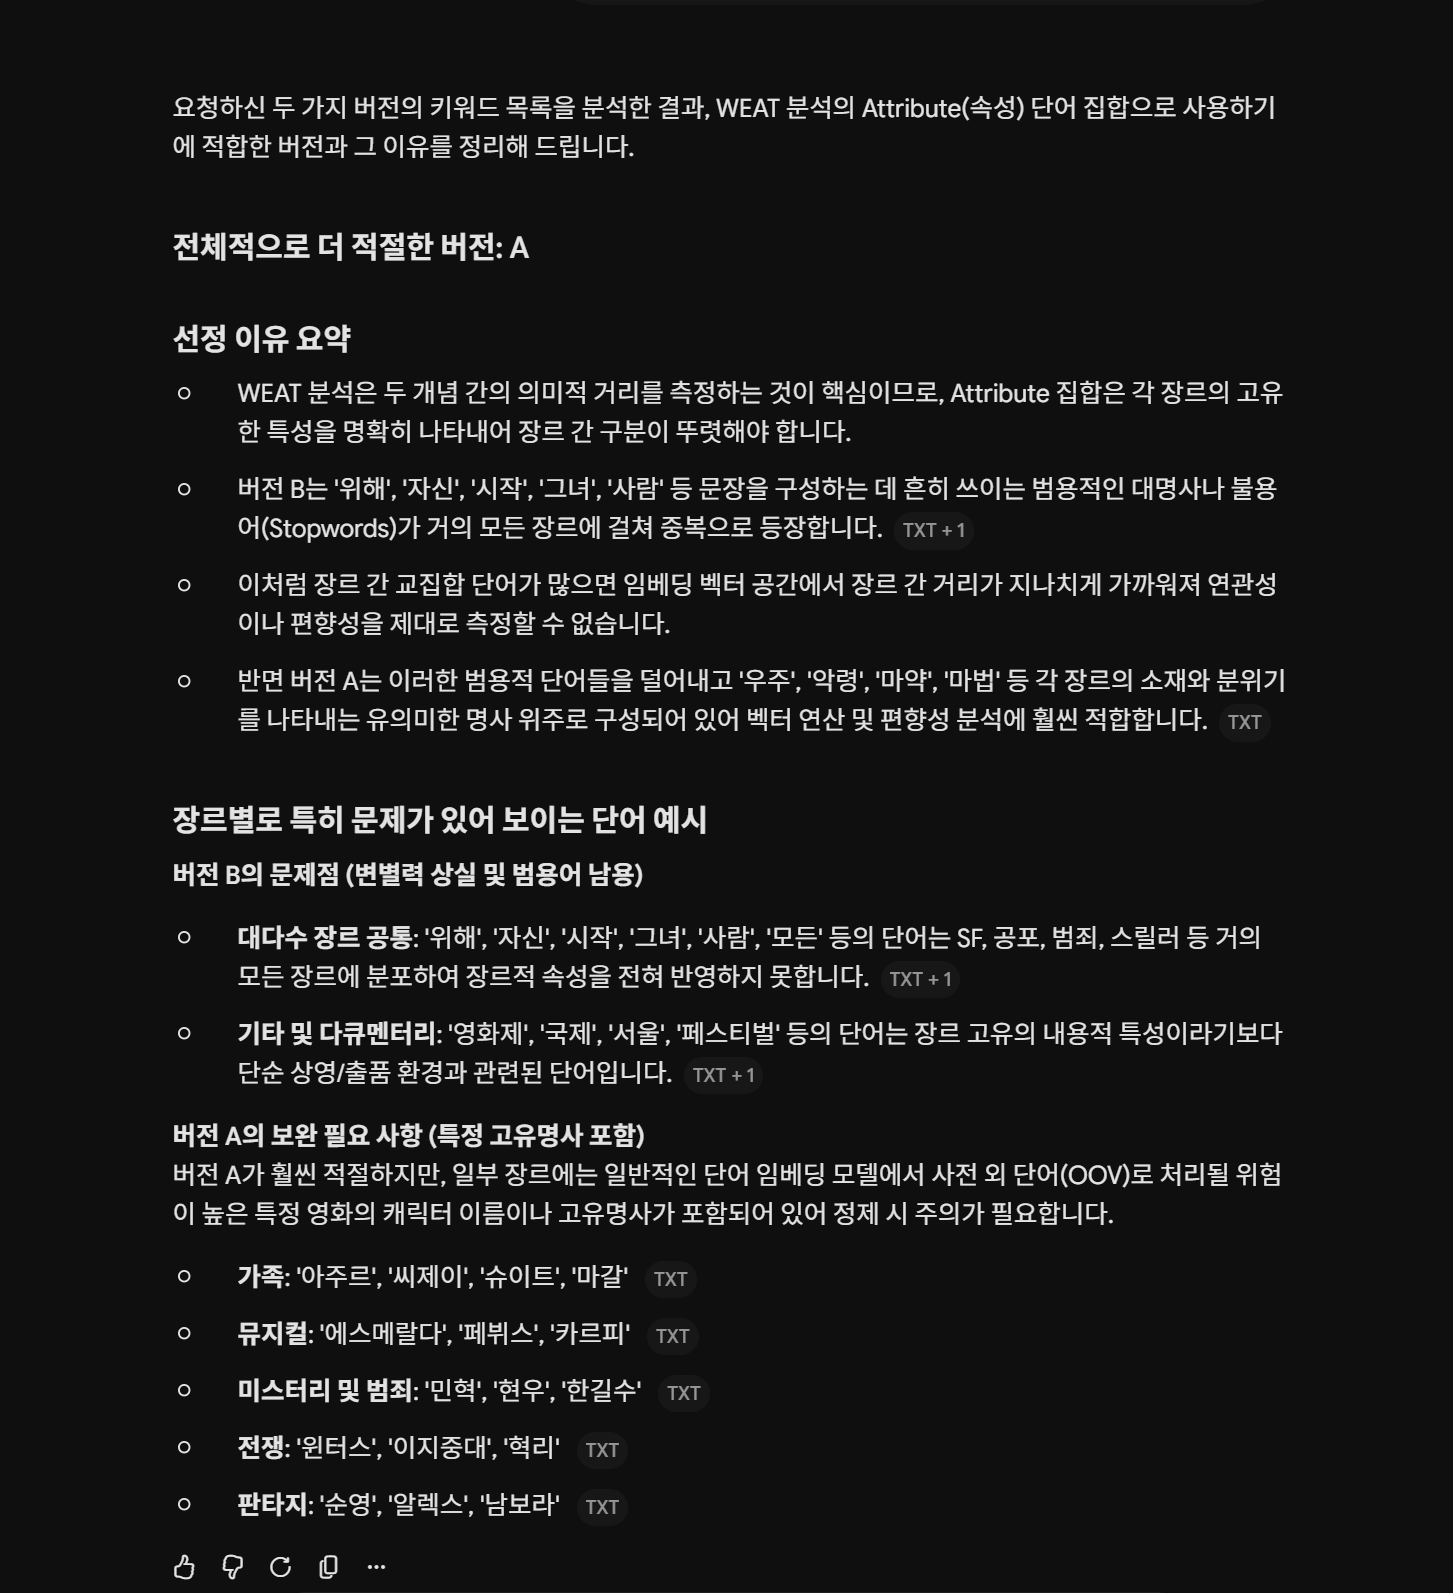

다행히도 개선판이 좋다고 한다.. 그리고 llm 또한 상술한 고유명사 문제를 짚어주었다. 
이제 다시 WEAT Score를 계산하여 시각화하고 차이점을 살펴보자. 



In [29]:
# 예술영화와 일반영화 target 단어 개선
TARGET_CANDIDATE_SIZE = 50
TARGET_FINAL_SIZE = 15
TARGET_INITIAL_SEARCH_SIZE = 100
TARGET_SEARCH_STEP = 100
TARGET_STOPWORDS = STOPWORDS.copy()

# 기존 target은 비교를 위해 그대로 보존합니다.
target_art_previous = list(target_art)
target_gen_previous = list(target_gen)

# 앞에서 vectorizer와 X가 다른 데이터에 사용되므로 target 전용 TF-IDF를 다시 생성합니다.
target_vectorizer_improved = TfidfVectorizer()
target_tfidf_matrix = target_vectorizer_improved.fit_transform([art, gen])
target_feature_names = target_vectorizer_improved.get_feature_names_out()

target_ranked_words = []
for row_idx in range(target_tfidf_matrix.shape[0]):
    sparse_row = target_tfidf_matrix[row_idx].tocoo()
    ranked_words = sorted(
        zip(sparse_row.col, sparse_row.data),
        key=lambda item: item[1],
        reverse=True,
    )
    target_ranked_words.append(ranked_words)

search_size = TARGET_INITIAL_SEARCH_SIZE
max_search_size = max(len(words) for words in target_ranked_words)

while True:
    search_size = min(search_size, max_search_size)
    scoped_candidates = []

    for ranked_words in target_ranked_words:
        valid_words = []

        for feature_idx, _ in ranked_words[:search_size]:
            word = target_feature_names[feature_idx]

            if word in TARGET_STOPWORDS or word not in model.wv:
                continue

            valid_words.append(word)

        scoped_candidates.append(valid_words)

    shared_words = set(scoped_candidates[0]) & set(scoped_candidates[1])
    art_unique_candidates = [
        word for word in scoped_candidates[0] if word not in shared_words
    ]
    gen_unique_candidates = [
        word for word in scoped_candidates[1] if word not in shared_words
    ]

    if (
        len(art_unique_candidates) >= TARGET_CANDIDATE_SIZE
        and len(gen_unique_candidates) >= TARGET_CANDIDATE_SIZE
    ):
        break

    if search_size == max_search_size:
        raise ValueError(
            "stopword와 공통 단어를 제외한 target 후보를 "
            f"각각 {TARGET_CANDIDATE_SIZE}개 확보할 수 없습니다. "
            f"예술영화: {len(art_unique_candidates)}개, "
            f"일반영화: {len(gen_unique_candidates)}개"
        )

    search_size += TARGET_SEARCH_STEP

target_art_candidates = art_unique_candidates[:TARGET_CANDIDATE_SIZE]
target_gen_candidates = gen_unique_candidates[:TARGET_CANDIDATE_SIZE]
target_art_improved = target_art_candidates[:TARGET_FINAL_SIZE]
target_gen_improved = target_gen_candidates[:TARGET_FINAL_SIZE]

# 구현 검증
assert target_art == target_art_previous
assert target_gen == target_gen_previous
assert len(target_art_candidates) == TARGET_CANDIDATE_SIZE
assert len(target_gen_candidates) == TARGET_CANDIDATE_SIZE
assert len(target_art_improved) == TARGET_FINAL_SIZE
assert len(target_gen_improved) == TARGET_FINAL_SIZE
assert TARGET_STOPWORDS.isdisjoint(target_art_improved)
assert TARGET_STOPWORDS.isdisjoint(target_gen_improved)
assert set(target_art_improved).isdisjoint(target_gen_improved)
assert all(word in model.wv for word in target_art_improved)
assert all(word in model.wv for word in target_gen_improved)

print(f"TF-IDF 검색 범위: 상위 {search_size}개")
print(f"기존 예술영화 target: {target_art_previous}")
print(f"개선 예술영화 target: {target_art_improved}")
print(f"기존 일반영화 target: {target_gen_previous}")
print(f"개선 일반영화 target: {target_gen_improved}")

TF-IDF 검색 범위: 상위 400개
기존 예술영화 target: ['아빠', '음악', '결심', '운명', '지금', '여인', '이름', '이후', '준비', '감정', '만난', '처음', '충격', '누구', '그린']
개선 예술영화 target: ['파리', '편지', '무대', '고양이', '천재', '첫사랑', '행복', '성공', '북한', '우정', '소설', '이별', '추억', '밴드', '예술']
기존 일반영화 target: ['서울', '애니메이션', '여성', '가지', '주인공', '대해', '연출', '사회', '다큐멘터리', '부문', '섹스', '바로', '의도', '계획', '정체']
개선 일반영화 target: ['애니메이션', '연출', '부문', '의도', '독립', '경쟁', '부천', '페스티벌', '환경', '다큐', '영상', '판타스틱', '유혹', '공격', '표현']


### 개선된 대표 단어를 이용한 WEAT 재분석

stopword와 공통 단어를 제외해 갱신한 `target_art_improved`, `target_gen_improved`와 장르별 `attributes_improved`를 이용해 WEAT score를 다시 계산한다. 기존 target, attribute, WEAT 결과는 유지하고 개선 결과는 별도의 변수에 저장한다.

In [30]:
# 개선된 대표 단어를 이용한 WEAT score 계산
target_art_vectors = np.array([model.wv[word] for word in target_art_improved])
target_gen_vectors = np.array([model.wv[word] for word in target_gen_improved])

missing_attribute_words = [
    word
    for genre_words in attributes_improved
    for word in genre_words
    if word not in model.wv
]

if missing_attribute_words:
    raise ValueError(
        f"Word2Vec에 없는 개선 대표 단어가 있습니다: {missing_attribute_words}"
    )

num_genres_weat = len(genre_name)
matrix_improved = np.zeros((num_genres_weat, num_genres_weat), dtype=float)
calculated_pair_count = 0

for genre_a_idx in range(num_genres_weat - 1):
    for genre_b_idx in range(genre_a_idx + 1, num_genres_weat):
        attribute_a_vectors = np.array([
            model.wv[word] for word in attributes_improved[genre_a_idx]
        ])
        attribute_b_vectors = np.array([
            model.wv[word] for word in attributes_improved[genre_b_idx]
        ])

        matrix_improved[genre_a_idx, genre_b_idx] = weat_score(
            target_art_vectors,
            target_gen_vectors,
            attribute_a_vectors,
            attribute_b_vectors,
        )
        calculated_pair_count += 1

upper_triangle_indices = np.triu_indices(num_genres_weat, k=1)

assert matrix_improved.shape == (num_genres_weat, num_genres_weat)
assert calculated_pair_count == num_genres_weat * (num_genres_weat - 1) // 2
assert len(attributes_improved) == num_genres_weat
assert all(len(words) == FINAL_SIZE for words in attributes_improved)
assert np.all(np.isfinite(matrix_improved[upper_triangle_indices]))

print(f"개선 WEAT 계산 완료: {calculated_pair_count}개 장르 쌍")

개선 WEAT 계산 완료: 210개 장르 쌍


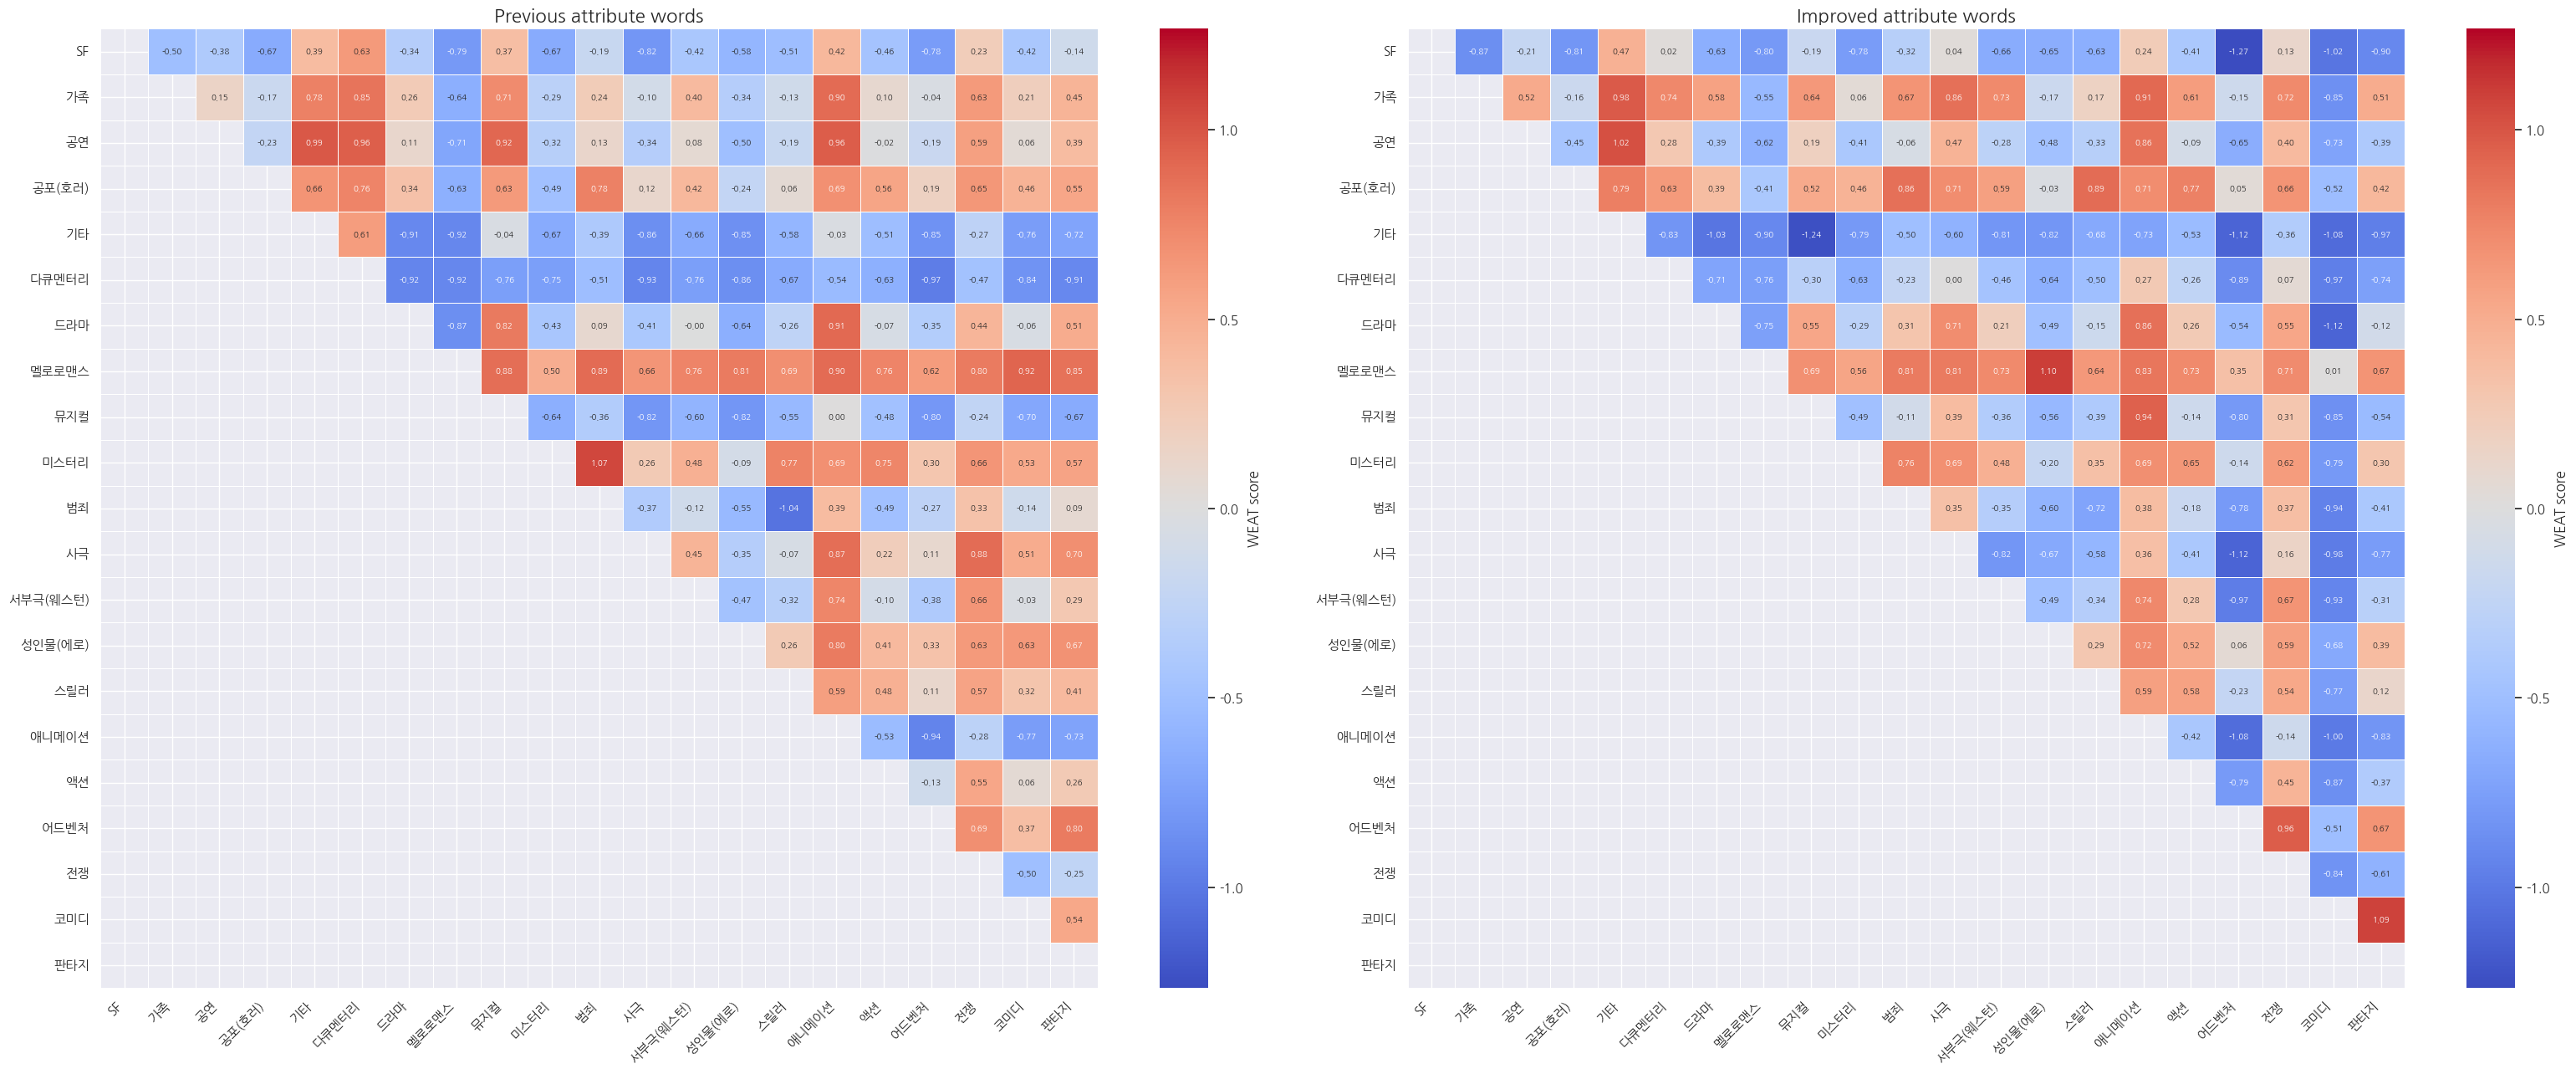

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# 동일한 색상 범위를 사용해야 두 히트맵의 점수 크기를 공정하게 비교할 수 있습니다.
matrix_previous_np = np.asarray(matrix, dtype=float)
matrix_improved_np = np.asarray(matrix_improved, dtype=float)
assert matrix_previous_np.shape == matrix_improved_np.shape
heatmap_mask = np.tril(np.ones_like(matrix_previous_np, dtype=bool))

comparison_values = np.concatenate([
    matrix_previous_np[~heatmap_mask],
    matrix_improved_np[~heatmap_mask],
])
shared_max_abs = np.max(np.abs(comparison_values))
assert shared_max_abs >= np.max(np.abs(matrix_previous_np[~heatmap_mask]))
assert shared_max_abs >= np.max(np.abs(matrix_improved_np[~heatmap_mask]))

if shared_max_abs == 0:
    shared_max_abs = 1.0

fig, axes = plt.subplots(1, 2, figsize=(32, 13))

heatmap_settings = {
    "mask": heatmap_mask,
    "xticklabels": genre_name,
    "yticklabels": genre_name,
    "cmap": "coolwarm",
    "center": 0,
    "vmin": -shared_max_abs,
    "vmax": shared_max_abs,
    "annot": True,
    "fmt": ".2f",
    "annot_kws": {"size": 7},
    "linewidths": 0.5,
    "cbar_kws": {"label": "WEAT score"},
}

sns.heatmap(matrix_previous_np, ax=axes[0], **heatmap_settings)
sns.heatmap(matrix_improved_np, ax=axes[1], **heatmap_settings)

axes[0].set_title("Previous attribute words", fontsize=16)
axes[1].set_title("Improved attribute words", fontsize=16)

for axis in axes:
    axis.tick_params(axis="x", rotation=45)
    axis.tick_params(axis="y", rotation=0)
    for label in axis.get_xticklabels():
        label.set_horizontalalignment("right")

plt.tight_layout()
plt.show()

In [32]:
from IPython.display import display

def calculate_mean_art_association(score_matrix):
    """각 장르 관점에서 다른 모든 장르와의 평균 WEAT 연관 점수를 계산합니다."""
    score_matrix_np = np.asarray(score_matrix, dtype=float)
    mean_scores = []

    for genre_idx in range(len(genre_name)):
        genre_pair_scores = []

        for row_idx in range(len(genre_name)):
            for col_idx in range(row_idx + 1, len(genre_name)):
                pair_score = score_matrix_np[row_idx, col_idx]

                if genre_idx == row_idx:
                    genre_pair_scores.append(pair_score)
                elif genre_idx == col_idx:
                    genre_pair_scores.append(-pair_score)

        mean_scores.append(float(np.mean(genre_pair_scores)))

    return mean_scores


previous_mean_scores = calculate_mean_art_association(matrix_previous_np)
improved_mean_scores = calculate_mean_art_association(matrix_improved_np)

# 점수가 같을 경우 기존 genre_name 순서를 기준으로 안정적으로 순위를 부여합니다.
previous_order = sorted(
    range(len(genre_name)),
    key=lambda idx: (-previous_mean_scores[idx], idx),
)
improved_order = sorted(
    range(len(genre_name)),
    key=lambda idx: (-improved_mean_scores[idx], idx),
)

previous_rank_by_genre = {
    genre_name[genre_idx]: rank
    for rank, genre_idx in enumerate(previous_order, start=1)
}
improved_rank_by_genre = {
    genre_name[genre_idx]: rank
    for rank, genre_idx in enumerate(improved_order, start=1)
}

rank_comparison_records = []

for genre_idx, genre_label in enumerate(genre_name):
    previous_rank = previous_rank_by_genre[genre_label]
    improved_rank = improved_rank_by_genre[genre_label]

    rank_comparison_records.append({
        "genre": genre_label,
        "previous_score": previous_mean_scores[genre_idx],
        "improved_score": improved_mean_scores[genre_idx],
        "previous_rank": previous_rank,
        "improved_rank": improved_rank,
        "rank_change": previous_rank - improved_rank,
    })

weat_rank_comparison_df = pd.DataFrame(rank_comparison_records).sort_values(
    "improved_rank"
).reset_index(drop=True)

expected_ranks = list(range(1, len(genre_name) + 1))
assert sorted(weat_rank_comparison_df["previous_rank"].tolist()) == expected_ranks
assert sorted(weat_rank_comparison_df["improved_rank"].tolist()) == expected_ranks
assert int(weat_rank_comparison_df["rank_change"].sum()) == 0

def color_rank_change(value):
    if value > 0:
        return "color: red; font-weight: bold"
    if value < 0:
        return "color: blue; font-weight: bold"
    return ""


weat_rank_comparison_styled = (
    weat_rank_comparison_df.style
    .format({
        "previous_score": "{:.4f}",
        "improved_score": "{:.4f}",
        "rank_change": "{:+d}",
    })
    .applymap(color_rank_change, subset=["rank_change"])
)

print("rank_change가 양수이면 개선 후 순위 상승, 음수이면 순위 하락입니다.")
display(weat_rank_comparison_styled)

rank_change가 양수이면 개선 후 순위 상승, 음수이면 순위 하락입니다.


,genre,previous_score,improved_score,previous_rank,improved_rank,rank_change
0,코미디,0.0337,0.8269,12,1,+11
1,멜로로맨스,0.7761,0.6712,1,2,-1
2,어드벤처,0.2963,0.5599,6,3,+3
3,공포(호러),0.3293,0.4458,5,4,+1
4,가족,0.2232,0.3852,8,5,+3
5,성인물(에로),0.4612,0.3292,3,6,-3
6,미스터리,0.4878,0.2854,2,7,-5
7,판타지,-0.1840,0.1400,14,8,+6
8,스릴러,0.2503,0.1396,7,9,-2
9,드라마,0.0569,0.0897,10,10,+0


---
### 결과 및 회고 
개선 전후 장르별 평균 WEAT 편향성을 비교한 결과 멜로로맨스는 두 방식 모두에서 예술영화 target과 강한 연관을 보여주었다. 이는 시놉시스 데이터에서 멜로로맨스 관련 단어들이 예술영화 target 단어와 가까운 문맥에서 학습되었음을 의미한다.   
코미디는 기존 11위에서 개선 후 2위로 크게 상승하였는데 이는 개선 후 코미디 attribute가 인생, 사랑, 친구, 결혼, 마음 등 감정·관계·생활 중심 단어로 구성되면서 예술영화 target과 더 가까워진 결과로 볼 수 있다.   
공포(호러), 어드벤처, 가족 역시 개선 후 예술영화 target 쪽의 상대적 연관성이 비교적 높게 나타났다. 반대로 기타, 다큐멘터리, 애니메이션, SF, 전쟁 등은 개선 후에도 상업영화 target 쪽에 가까운 방향을 보였다.  
특히 다큐멘터리는 개선 전후 모두 하위권에 머물렀다. 이는 일반적인 상식과 다를 수 있으나, 다큐멘터리 장르 자체의 예술성이 낮다는 의미로 해석할것이 아니라 다큐멘터리 대표 단어가 예술영화 target보다 상업영화 target과 더 가까운 임베딩 문맥을 형성한 것 그 이상도 이하도 아니며, target도 attribute도 완벽히 골라진 단어가 아닌 이상 한계가 있다. 
수정 이후에 장르들의 대표 단어는 많이 좋아졌다고 생각했는데 편향성 분석과 실제 나의 생각 간의 차이가 여전히 많이 나서 끝없는 비교실험과 튜닝의 필요성을 뼈저리게 느꼈다. 